<a href="https://colab.research.google.com/github/AarushMuthukrishnan/Machine-Learning-Notebooks/blob/main/6.%20V2%20-%20HAM10000_Skin_Cancer_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **WARNING**
**THIS DATASET CONTAINS IMAGES THAT SOME MAY NOT BE COMFORTABLE LOOKING AT AND/OR WORKING WITH**

# HAM10000 - Detection of Skin Cancer using SVMs, Neural Nets, and XGBoost

## Intro


In this notebook, we will dive deep into creating a model to predict/detect various types of skin cancer. To accomplish this, we will be exploring 3 different methods:


1.   Support Vector Machine(SVM), specifically using an SGD optimizer
2.   Image Classification Neural Network
3.   CNN–XGBoost Combination

These will be split up into sections, but a lot of information and variables are carried on and used between sections. We will start with an EDA of our dataset, then move on to creating and evaluating our different models.




## Objective

The HAM10000 dataset, as the name suggest, contains about 10,000 images of various types of skin cancer. Our goal is to create a model that can predict the type of skin cancer based on a given image with a sufficient accuracy.

## Setup

### Environment Setup
Let's start off by importing all libraries/packages we will be using for this project. Comments have been included for the purpose of each:

In [ ]:
# To import the dataset
import kagglehub

# File and data processing
import matplotlib.pyplot as plt
import numpy as np
import PIL
import pandas as pd

# Assist in file management later on
import shutil
import os
import pathlib

# SKLearn libraries for our SVM model
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, f1_score, average_precision_score
from sklearn.utils import class_weight

# Tensorflow libraries for neural net creation
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, losses
from tensorflow.keras.models import Sequential, Model

# Import XGBoost Library
import xgboost as xgb

To keep results universal on all machines, we will set a random state for our models:

In [ ]:
random_state = 67

### Dataset Load In

Let's now download the HAM10000 dataset from kaggle:

In [ ]:
kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.


'/kaggle/input/skin-cancer-mnist-ham10000'

From now on, many of the paths to files may difer in different environemnts.

If you take a look at the file structure...

In [ ]:
for r, d, f in os.walk("/kaggle/input/skin-cancer-mnist-ham10000"):
  print(r[40:])
for r, d, f in os.walk("/kaggle/input/skin-cancer-mnist-ham10000"):
  for i in range(4):
    print(f[i])
  break


/HAM10000_images_part_1
/ham10000_images_part_1
/HAM10000_images_part_2
/ham10000_images_part_2
hmnist_8_8_RGB.csv
hmnist_28_28_RGB.csv
hmnist_8_8_L.csv
hmnist_28_28_L.csv


...we see that there are 2 ways we can use this dataset. One way is to use the folders containing all images as files, as shown here:

In [ ]:
for r, d, f in os.walk("/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1"):
  print(f)

['ISIC_0028933.jpg', 'ISIC_0028394.jpg', 'ISIC_0027799.jpg', 'ISIC_0028100.jpg', 'ISIC_0027960.jpg', 'ISIC_0028872.jpg', 'ISIC_0026412.jpg', 'ISIC_0024872.jpg', 'ISIC_0026232.jpg', 'ISIC_0027031.jpg', 'ISIC_0026692.jpg', 'ISIC_0025729.jpg', 'ISIC_0028582.jpg', 'ISIC_0024754.jpg', 'ISIC_0027742.jpg', 'ISIC_0025408.jpg', 'ISIC_0026474.jpg', 'ISIC_0027164.jpg', 'ISIC_0027228.jpg', 'ISIC_0028059.jpg', 'ISIC_0028588.jpg', 'ISIC_0029299.jpg', 'ISIC_0027221.jpg', 'ISIC_0024912.jpg', 'ISIC_0028259.jpg', 'ISIC_0025844.jpg', 'ISIC_0028090.jpg', 'ISIC_0025454.jpg', 'ISIC_0028842.jpg', 'ISIC_0026980.jpg', 'ISIC_0026662.jpg', 'ISIC_0025037.jpg', 'ISIC_0025876.jpg', 'ISIC_0024901.jpg', 'ISIC_0025611.jpg', 'ISIC_0027201.jpg', 'ISIC_0025536.jpg', 'ISIC_0027941.jpg', 'ISIC_0026620.jpg', 'ISIC_0026352.jpg', 'ISIC_0026239.jpg', 'ISIC_0025595.jpg', 'ISIC_0026534.jpg', 'ISIC_0027384.jpg', 'ISIC_0026476.jpg', 'ISIC_0025575.jpg', 'ISIC_0024862.jpg', 'ISIC_0025553.jpg', 'ISIC_0027136.jpg', 'ISIC_0025702.jpg',

The files are split into 2 folders/parts, so we will later combine them into one.

The other way is to use the CSV files provided which already have the pixels of each image with an option of the images being in size 28x28 or 8x8:

In [ ]:
for r, d, f in os.walk("/kaggle/input/skin-cancer-mnist-ham10000"):
  for i in range(4):
    print(f[i])
  break

hmnist_8_8_RGB.csv
hmnist_28_28_RGB.csv
hmnist_8_8_L.csv
hmnist_28_28_L.csv


Because we have two different ways of doing this, we will test both.

### Stage 1 Data Setup

Let's start off with setting up our CSV files. We will use both the 8-pixel and 28-pixel files, as well as their RGB colored versions, to train 4 models using SKLearn.

Additionally, we have our legend providing the corresponding details for each image. Let's load in all files:

In [ ]:
legend = pd.read_csv("/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv")
pixel8 = pd.read_csv("/kaggle/input/skin-cancer-mnist-ham10000/hmnist_8_8_L.csv")
pixel28 = pd.read_csv("/kaggle/input/skin-cancer-mnist-ham10000/hmnist_28_28_L.csv")
pixel8RGB = pd.read_csv("/kaggle/input/skin-cancer-mnist-ham10000/hmnist_8_8_RGB.csv")
pixel28RGB = pd.read_csv("/kaggle/input/skin-cancer-mnist-ham10000/hmnist_28_28_RGB.csv")

For our project, we will combine the legend and pixel values so that we can feed in all our details as well as the images to the model:


In [ ]:
dt8 = legend.join(pixel8)
dt28 = legend.join(pixel28)
dt8RGB = legend.join(pixel8RGB)
dt28RGB = legend.join(pixel28RGB)

### Stage 2 Data Setup

Now, before we get into exploring our data, let us segment the image files themeselves into respect folders. This will come in handy when creating our neural network as we will see Tensorflow handling this structure with ease.

This code can seem a bit confusing at first, but all we are doing is taking each file from both Part 1 and Part 2 folders and placing them in their respective folders. Comments throughout the code will futher detail the process.

Let's first make sure we are in the home directory before creating our folder structure:

In [ ]:
os.chdir("/")

Now, let's create a folder for the dataset as well as mini folders inside for each type of skin cancer:

In [ ]:
os.mkdir("/HAM10000")
for i in legend["dx"].unique():
  os.mkdir(f"/HAM10000/{i}")

FileExistsError: [Errno 17] File exists: '/HAM10000'

To move the images from both folder parts, we have created a function that takes in the source folder, the destination folder, and the legend to follow:

In [ ]:
def moveImages(src, dst, legend):
  # Loop through all files in the legend, skip if file not found in given folder
  for i in range(len(legend)):
    try:
      # Move all files to their respective location using the legend
      src_path = f"/{src}/{legend["image_id"][i]}.jpg"
      dst_path = f"/{dst}/{legend["dx"][i]}/{legend["image_id"][i]}.jpg"
      shutil.move(src_path, dst_path)
    except:
      continue

Using our function, let's take all files from both folders and move them. This may take 1-2 minutes depending on your machine:

In [ ]:
moveImages("kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1", "HAM10000", legend)
moveImages("kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2", "HAM10000", legend)

Before we move on, let's take a quick look into how many of each type of skin cancer exists and ensure all our data has been properly transferred:

In [ ]:
new = 0
for i in legend["dx"].unique():
  print(i, (len([name for name in os.listdir(f'/HAM10000/{i}')])))
  new += (len([name for name in os.listdir(f'/HAM10000/{i}')]))
initial = (len([name for name in os.listdir("/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1")])) + len([name for name in os.listdir("/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2")])
print("-" * 35)
print("Initial Folder Count: ", initial)
print("New Folder Count: ", new)
if new == initial:
  print("All Data Succesfully Transferred!")
else:
  print("Something went wrong!")

bkl 1099
nv 6705
df 115
mel 1113
vasc 142
bcc 514
akiec 327
-----------------------------------
Initial Folder Count:  10015
New Folder Count:  10015
All Data Succesfully Transferred!


Success! We also see the distributions of each type of skin cancer, which starts to lead into our data analysis. Keep in mind that this will impact our model as different types have more data for the model to train on than others.

## Exploratory Data Analysis

Now that we have our data loaded in, let's take a look at them, starting with our CSV files:

In [ ]:
dt8

,lesion_id,image_id,dx,dx_type,age,sex,localization,pixel0000,pixel0001,pixel0002,...,pixel0055,pixel0056,pixel0057,pixel0058,pixel0059,pixel0060,pixel0061,pixel0062,pixel0063,label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,172,182,191,...,159,171,181,201,192,184,183,171,157,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,98,149,170,...,135,83,159,186,185,192,181,143,58,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,165,164,179,...,169,152,171,185,189,193,176,168,151,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,109,159,167,...,101,79,146,170,167,158,154,133,45,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,173,202,210,...,230,160,199,206,208,209,205,200,186,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen,193,192,191,...,202,206,215,211,207,196,212,205,191,0
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen,93,139,165,...,137,145,185,194,186,183,180,161,88,0
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen,165,191,211,...,189,184,223,227,218,217,223,207,182,0
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face,138,152,154,...,172,143,161,167,166,174,184,175,168,0


In [ ]:
dt28

,lesion_id,image_id,dx,dx_type,age,sex,localization,pixel0000,pixel0001,pixel0002,...,pixel0775,pixel0776,pixel0777,pixel0778,pixel0779,pixel0780,pixel0781,pixel0782,pixel0783,label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,169,171,170,...,184,186,185,180,157,140,140,159,165,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,19,57,105,...,172,175,160,144,114,89,47,18,18,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,155,163,161,...,163,178,157,166,167,148,141,136,115,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,25,71,116,...,125,135,138,137,111,71,32,16,16,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,129,162,181,...,210,197,172,190,195,193,181,147,88,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen,172,171,173,...,210,217,221,209,185,187,192,192,192,0
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen,2,34,108,...,173,169,168,168,143,138,83,23,3,0
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen,122,154,162,...,221,215,205,187,209,198,187,164,156,0
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face,137,143,141,...,172,171,175,183,177,170,169,166,170,0


In [ ]:
dt8RGB

,lesion_id,image_id,dx,dx_type,age,sex,localization,pixel0000,pixel0001,pixel0002,...,pixel0183,pixel0184,pixel0185,pixel0186,pixel0187,pixel0188,pixel0189,pixel0190,pixel0191,label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,199,156,188,...,214,167,191,199,157,175,184,143,167,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,115,87,115,...,207,167,188,177,128,138,74,51,60,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,203,146,164,...,211,160,175,199,152,172,177,138,158,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,135,96,110,...,179,141,157,153,122,138,58,39,46,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,204,156,187,...,236,189,213,233,182,209,207,175,188,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen,205,186,202,...,229,205,211,218,199,202,207,185,186,0
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen,103,89,88,...,199,172,173,179,154,152,99,84,80,0
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen,178,160,165,...,241,216,216,224,201,199,197,177,172,0
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face,166,124,142,...,195,178,187,191,168,177,186,159,169,0


In [ ]:
dt28RGB

,lesion_id,image_id,dx,dx_type,age,sex,localization,pixel0000,pixel0001,pixel0002,...,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351,label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,192,153,193,...,173,124,138,183,147,166,185,154,177,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,25,14,30,...,60,39,55,25,14,28,25,14,27,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,192,138,153,...,167,129,143,159,124,142,136,104,117,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,38,19,30,...,44,26,36,25,12,17,25,12,15,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,158,113,139,...,209,166,185,172,135,149,109,78,92,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen,183,165,181,...,208,185,187,208,186,186,206,187,189,0
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen,2,3,1,...,96,79,76,24,23,21,3,4,1,0
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen,132,118,118,...,204,181,178,181,159,153,172,151,145,0
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face,160,124,146,...,185,162,167,184,157,166,185,162,172,0


We see that all files have a similar structure, with the 28 pixel file having more columns to accomodate for the larger amount than the 8 pixel file.

Let's first show the impact of 8 pixels versus 28 pixels.

For pixel names for both non-RGB files, we see that the names range from 0 to 63 and 0 to 783, respectivley, meaning that there are 64 and 784 pixels representing each image, respectivley. These numbers come from squaring the size of the image, since the image is a square shape.

But now let's look at the RGB files. You can see that the pixel names for the 28 pixel file in RGB range from 0 to 2351, meaning there are 2352 pixels representing each column. While this doesn't immediately match our '28' number, we can get there with some calculations.

First note that these pixels work together to represent each pixel in RGB, or in otherwords: each 3 value pair represents one pixel. So dividing 2352 by 3, we get our familiar '784' number(which, again, is just 28 * 28 or 28 sqaured). This patern goes the same for the 8 pixel RGB file.

Now with this in mind, we can create a function to take in a file name, what pixel size we want, and whether we want it in RGB or not. We have written the function with comments explaining it below:

In [ ]:
def showImage(imageID, pixelSize = 28, isRGB = True):
  # Get index of row that image is located
  index = int(legend.loc[legend.image_id == f"ISIC_{imageID}"].index[0])

  # Handles RGB and grayscale images
  if isRGB:
    a = []
    b = []
    c = []

    acounter = 0
    bcounter = 0

    # Read list of pixel values into a list of either 8x3 or 28x3 lists
    for i in (pd.DataFrame(pixel8RGB.iloc[index])[index].to_list() if pixelSize == 8 else pd.DataFrame(pixel28RGB.iloc[index])[index].to_list()):
      a.append(i)
      acounter += 1
      if acounter == 3:
        b.append(a)
        bcounter += 1
        a = []
        acounter = 0
      if bcounter == pixelSize:
        c.append(b)
        b = []
        bcounter = 0

    # Convert to NumPy array and
    c = np.asarray(c)
    # Use MatPlotLib to display image
    plt.imshow(c)
    plt.axis('off')
    plt.show()
  else:
    a = []
    b = []
    acounter = 0

    # Read list of pixel values into a list of either 8x1 or 28x1 lists
    for i in (pd.DataFrame(pixel8.iloc[index])[index].to_list() if pixelSize == 8 else pd.DataFrame(pixel28.iloc[index])[index].to_list()):
      a.append(i)
      acounter += 1
      if acounter == pixelSize:
        b.append(a)
        acounter = 0
        a = []

    # Convert to NumPy array
    b = np.asarray(b)
    # Use MatPlotLib to display image
    plt.imshow(b, cmap='gray')
    plt.axis('off')
    plt.show()

We can now use our handy function to look at one of our images in RGB and grayscale, each in 8x8 pixels and 28x28 pixels:

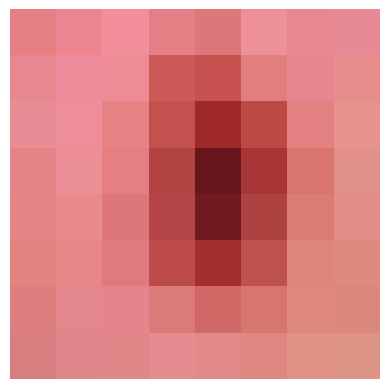

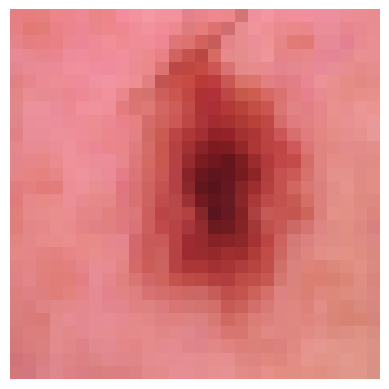

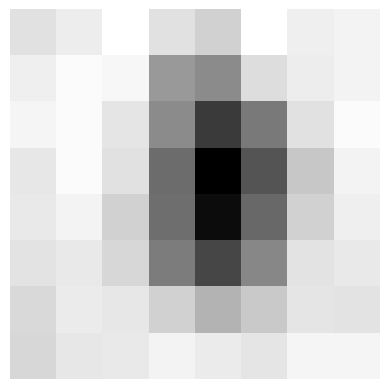

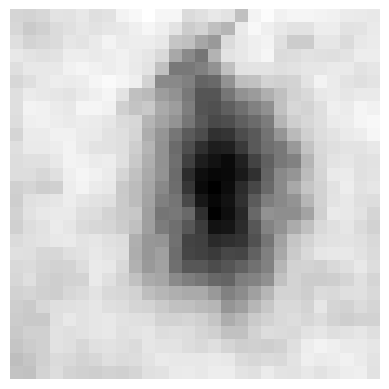

In [ ]:
showImage("0024306", 8, True)
showImage("0024306", 28, True)
showImage("0024306", 8, False)
showImage("0024306", 28, False)

We can see how different and 8x8 image is compared to a 28x28 image, as well as the amount of detail that can be added just from making the images colored.

Let's now look into some statistics for our additional data in our dataset, as shown here:

In [ ]:
legend

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear
...,...,...,...,...,...,...,...
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face


We see the amount of rows is 10015, which will be a key number throughout this notebook as that is the amount of images in the dataset we have to work with.

We can look at some data for the ages:

In [ ]:
legend["age"].describe()

,age
count,9958.000000
mean,51.863828
std,16.968614
min,0.000000
25%,40.000000
50%,50.000000
75%,65.000000
max,85.000000


We can see many information here, such as the average age being 51 and the highest age being 85. We do see 2 peculiar datapoints, specifically the count being 9958 and the minimum being 0. Not only does our dataset contain 10015 images instead of 9958, but having an age of 0 doesn't make sense either. This starts to hint at some discrepancy in our data, specifically some potential missing data that needs to be handeled with.

For the rest of the columns, such as "dx"(the type of skin cancer the image is classified as, each being abbreviated), "dx_type"(how the skin cancer was detected), "sex", and "localization"(where the skin cancer was detected), let's look at each of their unique values:

In [ ]:
print(legend["dx"].unique().tolist())
print(legend["dx_type"].unique().tolist())
print(legend["sex"].unique().tolist())
print(legend["localization"].unique().tolist())

['bkl', 'nv', 'df', 'mel', 'vasc', 'bcc', 'akiec']
['histo', 'consensus', 'confocal', 'follow_up']
['male', 'female', 'unknown']
['scalp', 'ear', 'face', 'back', 'trunk', 'chest', 'upper extremity', 'abdomen', 'unknown', 'lower extremity', 'genital', 'neck', 'hand', 'foot', 'acral']


Not only do we get a better understanding of the different types of data we have, but we also start to notice many "unkown" values showing up. Because there isn't much more we can analyze in this data as the main focus point are the images, let us begin to clean up our data.

Note that we aren't doing an EDA for Stage 2(Neural Network) as the data we are working with is primarly the image files.

## Feature Engineering

Many of our current columns won't be usefull to our model and may in fact confuse it, such as "lesion_id", "image_id", "dx"(we will use the numerical labels provided in the pixel dataset), and "dx_type"(in a real application, this data may not be provided/be appicable). Let's drop those from all our 4 data frames:

In [ ]:
for column in ["lesion_id", "image_id", "dx", "dx_type"]:
  dt8 = dt8.drop(column, axis=1)
  dt28 = dt28.drop(column, axis=1)
  dt8RGB = dt8RGB.drop(column, axis=1)
  dt28RGB = dt28RGB.drop(column, axis=1)


Now if we look at our 8-pixel grayscale data frame, we see we only have our needed information:

In [ ]:
dt8

,age,sex,localization,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,...,pixel0055,pixel0056,pixel0057,pixel0058,pixel0059,pixel0060,pixel0061,pixel0062,pixel0063,label
0,80.0,male,scalp,172,182,191,183,180,181,165,...,159,171,181,201,192,184,183,171,157,2
1,80.0,male,scalp,98,149,170,193,183,162,164,...,135,83,159,186,185,192,181,143,58,2
2,80.0,male,scalp,165,164,179,172,152,163,169,...,169,152,171,185,189,193,176,168,151,2
3,80.0,male,scalp,109,159,167,166,163,159,155,...,101,79,146,170,167,158,154,133,45,2
4,75.0,male,ear,173,202,210,194,208,248,243,...,230,160,199,206,208,209,205,200,186,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10010,40.0,male,abdomen,193,192,191,198,182,191,213,...,202,206,215,211,207,196,212,205,191,0
10011,40.0,male,abdomen,93,139,165,183,188,180,150,...,137,145,185,194,186,183,180,161,88,0
10012,40.0,male,abdomen,165,191,211,227,222,208,210,...,189,184,223,227,218,217,223,207,182,0
10013,80.0,male,face,138,152,154,161,173,177,179,...,172,143,161,167,166,174,184,175,168,0


Remember during our EDA we say many occurences of missing values? We can now remove all those to have a clean dataset:

In [ ]:
dt8 = dt8.dropna()
dt28 = dt28.dropna()
dt8RGB = dt8RGB.dropna()
dt28RGB = dt28RGB.dropna()

Now if we take a look at the shape of any one of the data frames...

In [ ]:
dt8.shape

(9958, 68)

...we see that the number of rows dropped from 10015 to 9958, meaning that 57 columns had some missing values and were dropped. While we did loose some data, the amount we lost does not greatly affect the model and would have in fact hurt the model if values were kept missing.

Now, we want to handle all non-numerical columns, specifically the "sex" and "localization" columns. We can use a label encoder to handle these so that the model can take in these values:

In [ ]:
le = LabelEncoder()
dt8["sex"] = le.fit_transform(dt8["sex"])
dt8["localization"] = le.fit_transform(dt8["localization"])

dt28["sex"] = le.fit_transform(dt28["sex"])
dt28["localization"] = le.fit_transform(dt28["localization"])

dt8RGB["sex"] = le.fit_transform(dt8RGB["sex"])
dt8RGB["localization"] = le.fit_transform(dt8RGB["localization"])

dt28RGB["sex"] = le.fit_transform(dt28RGB["sex"])
dt28RGB["localization"] = le.fit_transform(dt28RGB["localization"])

/tmp/ipykernel_464/1073566196.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dt8["sex"] = le.fit_transform(dt8["sex"])
/tmp/ipykernel_464/1073566196.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dt8["localization"] = le.fit_transform(dt8["localization"])


So if we now look at some sample data...

In [ ]:
dt8

,age,sex,localization,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,...,pixel0055,pixel0056,pixel0057,pixel0058,pixel0059,pixel0060,pixel0061,pixel0062,pixel0063,label
0,80.0,1,11,172,182,191,183,180,181,165,...,159,171,181,201,192,184,183,171,157,2
1,80.0,1,11,98,149,170,193,183,162,164,...,135,83,159,186,185,192,181,143,58,2
2,80.0,1,11,165,164,179,172,152,163,169,...,169,152,171,185,189,193,176,168,151,2
3,80.0,1,11,109,159,167,166,163,159,155,...,101,79,146,170,167,158,154,133,45,2
4,75.0,1,4,173,202,210,194,208,248,243,...,230,160,199,206,208,209,205,200,186,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10010,40.0,1,0,193,192,191,198,182,191,213,...,202,206,215,211,207,196,212,205,191,0
10011,40.0,1,0,93,139,165,183,188,180,150,...,137,145,185,194,186,183,180,161,88,0
10012,40.0,1,0,165,191,211,227,222,208,210,...,189,184,223,227,218,217,223,207,182,0
10013,80.0,1,5,138,152,154,161,173,177,179,...,172,143,161,167,166,174,184,175,168,0


## Stage 1 - Support Vector Machine(SVM) Using SKLearn

### Data Preparation

We are now ready to train our first model! For this model, we will be feeding all our data and training 4 models based on the size and color of the images. Let's start by splitting our data into their respective X and Y sets:

In [ ]:
x8 = dt8.drop("label", axis=1)
y8 = dt8["label"]

x28 = dt28.drop("label", axis=1)
y28 = dt28["label"]

x8RGB = dt8RGB.drop("label", axis=1)
y8RGB = dt8RGB["label"]

x28RGB = dt28RGB.drop("label", axis=1)
y28RGB = dt28RGB["label"]

We can take one of the y sets for example and see that the only column contains the skin cancer label type for each respective image:

In [ ]:
y8

,label
0,2
1,2
2,2
3,2
4,2
...,...
10010,0
10011,0
10012,0
10013,0


We can now split our datasets into a train and test set using an 80/20 split:

In [ ]:
x_train_8, x_test_8, y_train_8, y_test_8 = train_test_split(x8, y8, test_size=0.2, random_state=random_state)
x_train_28, x_test_28, y_train_28, y_test_28 = train_test_split(x28, y28, test_size=0.2, random_state=random_state)
x_train_8RGB, x_test_8RGB, y_train_8RGB, y_test_8RGB = train_test_split(x8RGB, y8RGB, test_size=0.2, random_state=random_state)
x_train_28RGB, x_test_28RGB, y_train_28RGB, y_test_28RGB = train_test_split(x28RGB, y28RGB, test_size=0.2, random_state=random_state)

### Model Training

Finally, we can train each of our 4 models. This will take a couple of minutes depending on your machine:

In [ ]:
sgd8 = SGDClassifier(random_state=random_state, class_weight='balanced')
sgd8.fit(x_train_8, y_train_8)

sgd28 = SGDClassifier(random_state=random_state, class_weight='balanced')
sgd28.fit(x_train_28, y_train_28)

sgd8RGB = SGDClassifier(random_state=random_state, class_weight='balanced')
sgd8RGB.fit(x_train_8RGB, y_train_8RGB)

sgd28RGB = SGDClassifier(random_state=random_state, class_weight='balanced')
sgd28RGB.fit(x_train_28RGB, y_train_28RGB)

SGDClassifier(class_weight='balanced', random_state=67)

We can now use our models to predict on their respective test sets:

In [ ]:
y_pred_8 = sgd8.predict(x_test_8)
y_pred_28 = sgd28.predict(x_test_28)
y_pred_8RGB = sgd8RGB.predict(x_test_8RGB)
y_pred_28RGB = sgd28RGB.predict(x_test_28RGB)

### Model Analysis

Now let's look at a classification report for each model:

In [ ]:
print(classification_report(y_test_8, y_pred_8))
print(classification_report(y_test_28, y_pred_28))
print(classification_report(y_test_8RGB, y_pred_8RGB))
print(classification_report(y_test_28RGB, y_pred_28RGB))

              precision    recall  f1-score   support

           0       0.17      0.14      0.15        73
           1       0.22      0.10      0.14       106
           2       0.27      0.01      0.02       230
           3       0.08      0.04      0.05        25
           4       0.70      0.89      0.78      1296
           5       0.00      0.00      0.00        33
           6       0.34      0.20      0.25       229

    accuracy                           0.61      1992
   macro avg       0.25      0.20      0.20      1992
weighted avg       0.55      0.61      0.56      1992

              precision    recall  f1-score   support

           0       0.22      0.03      0.05        73
           1       0.40      0.02      0.04       106
           2       0.20      0.63      0.30       230
           3       0.03      0.20      0.05        25
           4       0.85      0.67      0.75      1296
           5       0.00      0.00      0.00        33
           6       0.45 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

From what we can see, there isn't a scenario where one model dominated over another. We do see that for both RGB and grayscale data, the model overall did slightly better with 28 pixels and 8 pixels in general accuracy and an F-1 score. An interesting pattern we can see is that when the 8x8 images are given, the model does much better at classifying class 1 than class 2, and vice versa with the 28x28 scale images given. As for improvement with color, there are slight, but notable increases in accuracy amongst classes.

We can say that with these models, we are able to get an average model accuracy of around 60%. For a model that may be used to guide users, this is not feasible. Let's now see whether we can use neural networks to identify more complex features and get a higher overall performance/accuracy.

## Stage 2 - Image Classification Neural Network Using Tensorflow

### Data Preparation

Now let's train a neural network using the image folder we initially created.

Because these are images and we previously made sure that all images are sorted into their correctly labeled folders, there is no further data engineering needed as Tensorflow makes it very easy to train directly on our folder.

Let's first store our data folder path using pathlib:

In [ ]:
data_dir = pathlib.Path("/HAM10000")

We will now set our batch size and image dimensions to feed into the model. Note that the original image size is larger than 180x180, but for computational purposes, we will start out with a smaller size:

In [ ]:
batch_size = 32
img_height = 180
img_width = 180

Now, we can easily use tensorflow to form a training set with a 80/20 split:

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=random_state,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 10015 files belonging to 7 classes.
Using 8012 files for training.


We can do the same for a validation set:

In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=random_state,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 10015 files belonging to 7 classes.
Using 2003 files for validation.


We can now quickly see how easily Tensorflow detected our class names just from the folder names:

In [ ]:
class_names = train_ds.class_names
print(class_names)

['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


The following code makes sure that we retrieve our image data from cache to save memory as well as perform data preprocessing at the same time as model training. This way, our efficiency is boosting while training:

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

One last step: as we handeled class imbalance in our SVM model, we must also handle it for our CNN as well:

In [ ]:
train_labels = y_train_8.to_numpy()

computed_weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(train_labels), y=train_labels)

class_weight_dict = dict(enumerate(computed_weights))

### Level 1 Neural Net

#### Model Architecture Setup

Let's now set up our neural network. To start, we will be using a rather classic architecture:
*   1 Rescaling/Input Layer
*   3 Convolution Layers
*   3 MaxPooling Layers
*   1 Flattening Layer
*   2 Dense Layers

Let's implement this in our code:



In [ ]:
num_classes = len(class_names)

model = Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


We will use the standard Adam optimizer for this model. Let's now compile the model:

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

We can now take a look at our model's layers and parameters:

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,543 (15.22 MB)

 Trainable params: 3,989,543 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

#### Model Training

Finally, let us train the model. This may take some time depending on your machine:

In [ ]:
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=10,
  class_weight=class_weight_dict
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 65s 71ms/step - accuracy: 0.6694 - loss: 2.7930 - val_accuracy: 0.6605 - val_loss: 1.5323
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 24s 20ms/step - accuracy: 0.6717 - loss: 2.4046 - val_accuracy: 0.6610 - val_loss: 1.2055
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.6727 - loss: 2.2186 - val_accuracy: 0.6605 - val_loss: 1.5099
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.6775 - loss: 2.1109 - val_accuracy: 0.6680 - val_loss: 1.2905
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.6858 - loss: 1.9826 - val_accuracy: 0.6710 - val_loss: 1.2934
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.6958 - loss: 1.8212 - val_accuracy: 0.6735 - val_loss: 1.7272
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7028 - loss: 1.7359 - val_accuracy: 0.6830 - val_loss: 1.1152
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7232 - loss: 1.5143 - val_ac

#### Model Analysis

Now that our model is trained, let's plot the accuracy and loss for both the train and test set over the 10 epochs:

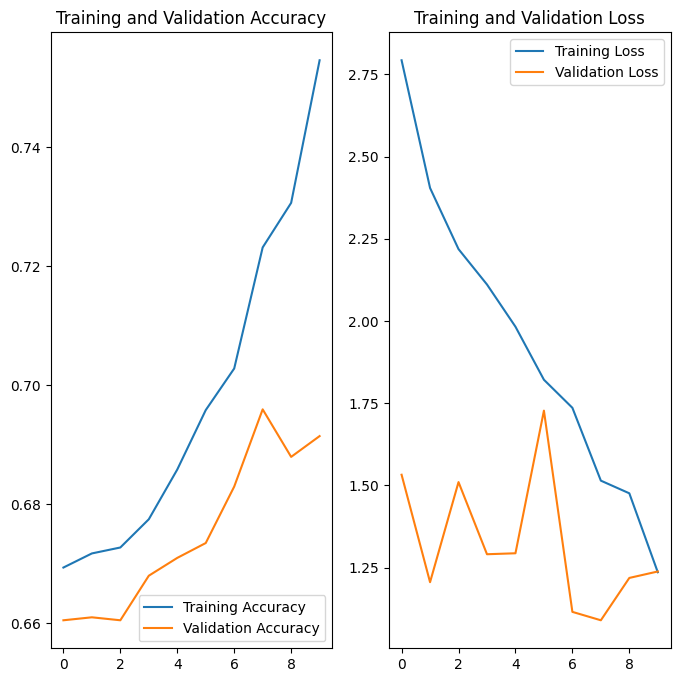

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(10)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

As we can see, the difference in accuracy between the training and validation is notable, with the training accuracy reaching a high of 74%, while the validation accuracy reaching a high of 70%. As for the loss, a similar pattern was shown for both the train and validation sets. We can see that for loss, the validation set started to do worse around epochs 8-9. This could be a sign of overfitting, so let's try and add more complexity to our model.

### Level 2 Neural Net

#### Model Architecture Setup

To handle overfitting, we will be implementing two strategies to our network:

1.   **Data Augmentation** Implement random transformations to the image dataset to act as "new data" for the model to test on
2.   **Dropout** Randomly "disable" different nodes of the network to add randomness

Let's start by setting up the Data Augmentation layer:



In [ ]:
data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal",
                      input_shape=(img_height,
                                  img_width,
                                  3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

Now, along with a Dropout layer, let's set up our new network architecture:

In [ ]:
model = Sequential([
  data_augmentation,
  layers.Rescaling(1./255),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes, name="outputs")
])

Let's now compile our new model:

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

Now let's look at our new network structure:

In [ ]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputs (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,543 (15.22 MB)

 Trainable params: 3,989,543 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

We can see that the amount of parameters didn't change, however, while training our new additions will come into play.

#### Model Training

Let's also increase the amount of epochs to 15 and train the model:

In [ ]:
epochs = 15
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs,
  class_weight=class_weight_dict
)

Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.6689 - loss: 2.8923 - val_accuracy: 0.6605 - val_loss: 1.3603
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.6717 - loss: 2.5293 - val_accuracy: 0.6605 - val_loss: 1.3372
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.6717 - loss: 2.4464 - val_accuracy: 0.6605 - val_loss: 1.3881
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.6717 - loss: 2.3481 - val_accuracy: 0.6605 - val_loss: 1.5053
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.6719 - loss: 2.2697 - val_accuracy: 0.6605 - val_loss: 1.4317
Epoch 6/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.6731 - loss: 2.2091 - val_accuracy: 0.6605 - val_loss: 1.2537
Epoch 7/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.6765 - loss: 2.1575 - val_accuracy: 0.6630 - val_loss: 1.3079
Epoch 8/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.6790 - loss: 2.0923 - val_acc

#### Model Analysis

Now that our model is trained, let's plot the accuracy and loss for both the train and test set over the 15 epochs:

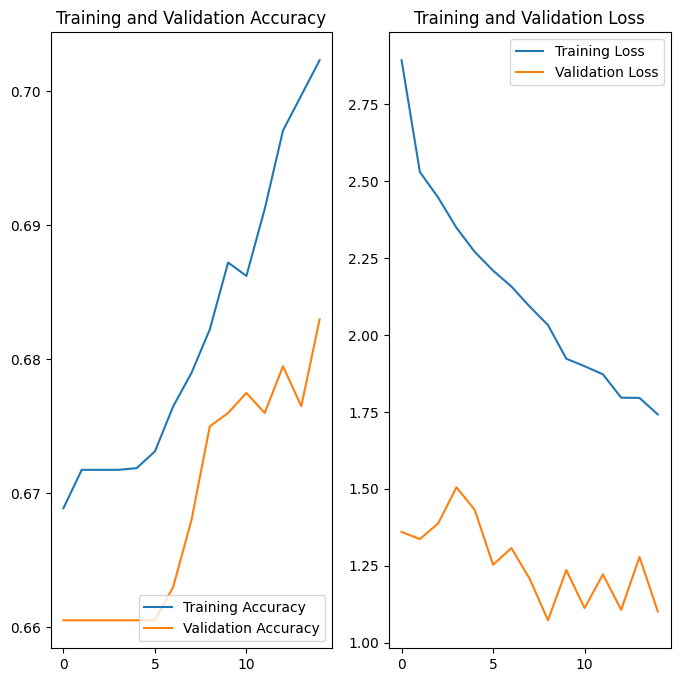

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

At first glance, it looks like the model actually did worse than previously, especially when the accuracy dropped from the previous 74% to now 70%. But in fact, there 2 major points that show the model did much better:

*   Validation accuracy was much closer to training accuracy
*   Both accuracy and loss continued to increase/decrease(respectively), meaning that more epochs would have probably served to a better performance.

This goes to show that our additions to the model did, in fact, help with overfitting.



## Stage 3 - XGBoost Classifier

### Model Architecture Setup

With all the models we have tested, let's see if we can combine the ideas of both. With the SVM model, we were not only able to feed the images, but also feed in additonal metadata. With our CNN, we were able to add complexity.

Now, we can implement an XGBoost classifier that takes the best of both worlds in this situation. The way we can do this is by taking the features from the CNN's penultimate layer and have the last layer instead be XGBoost classifier. Additionally, we will want to combine the image data and metadata. Because of the ensemble of trees that XGBoost uses to learn, each tree is able to catch the errors of the previous one.

Our first step is to set up the model. Let's first extract the penultimate layer of our trained CNN:

In [ ]:
extractor = Model(inputs=model.layers[0].input, outputs=model.layers[-2].output)

We can now look at the model summary to see that we have removed the last linear output layer where the XGBoost classifier will go:

In [ ]:
print(extractor.summary())

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │     3,965,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,988,640 (15.22 MB)

 Trainable params: 3,988,640 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

None


Now, let's use our extractor to get our features and labels from our training dataset:

In [ ]:
train_features = []
train_labels = []
for images, labels in train_ds:
  train_features.append(extractor.predict_on_batch(images))
  train_labels.extend(labels.numpy())

train_features = np.vstack(train_features)
train_labels = np.array(train_labels)

NameError: name 'train_ds' is not defined

And, of course, we must do the same for our validation set:

In [ ]:
val_features = []
val_labels = []
for images, labels in val_ds:
  val_features.append(extractor.predict_on_batch(images))
  val_labels.extend(labels.numpy())

val_features = np.vstack(val_features)
val_labels = np.array(val_labels)

Now that we have our training and validation features and labels, we can now setup our XGBoost classifier to train on these. We will set up a Randomized Grid Search to find an optimized set of parameters for our model in a shorter amount of time than a standard Grid Search. We will instruct the search to pick the best model based on it's weighted F1 score:

In [ ]:
xgb_model = xgb.XGBClassifier(
  objective = 'multi:softmax',
  num_class = len(class_names),
  eval_metric = 'mlogloss',
  tree_method = 'hist',
  device = 'cuda',
  random_state = random_state
)

param_grid = {
  'max_depth': [7, 10, 12],
  'learning_rate': [0.05, 0.1, 0.2],
  'n_estimators': [100, 200, 300],
  'subsample': [0.8, 1.0],
  'colsample_bytree': [0.8, 1.0]
}

clf = RandomizedSearchCV(
  estimator = xgb_model,
  param_distributions = param_grid,
  n_iter = 15,
  cv = 3,
  scoring='f1_weighted',
  random_state=random_state
)

clf.fit(train_features, train_labels)

RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device='cuda',
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='mlogloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_co...
                                           max_delta_step=None, max_depth=None,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_class=7, ...),
                   n_iter=15,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.05, 0.1, 0.2],
                                        'max_depth': [7, 10, 12],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.8, 1.0]},
                   random_state=67, scoring='f1_weighted')

Now that our model is trained, let's look at the classification report:

In [ ]:
modelXGB = clf.best_estimator_
xgbPred = modelXGB.predict(val_features)

print(classification_report(val_labels, xgbPred, target_names=class_names))

              precision    recall  f1-score   support

       akiec       0.36      0.39      0.38        56
         bcc       0.49      0.42      0.45       109
         bkl       0.48      0.38      0.42       236
          df       0.23      0.12      0.15        26
         mel       0.55      0.31      0.40       232
          nv       0.82      0.93      0.88      1323
        vasc       0.78      0.67      0.72        21

    accuracy                           0.74      2003
   macro avg       0.53      0.46      0.49      2003
weighted avg       0.71      0.74      0.72      2003



Our overall accuracy is around 75%, but just because this was equal or just below our previous 75%, this should defintely not be mistaken. The first big win we see here is that the F1-scores are now amazingly all distributed, as apposed to our previous model focus on just 'nv' since the dataset has a huge distribution shift towards that category. With this, not only is the F1-score distributed, but the precision and recall are as well. Achieving this standard as well as an accuracy of 75% is remarkable.

Now, one last step before we end off here. Because we trained this complex model along with the metadata, we can see exactly how well the model is generalizing between different demographic and scanner data by using:

*overall AUPRC − demographic AUPRC disparity − scanner AUPRC disparity*

First, we need to binarize our labels:

In [ ]:
classes = np.arange(len(class_names))
y_true_bin = label_binarize(val_labels, classes=classes)

Now, let's get the probabilities for our new model:

In [ ]:
y_probs = modelXGB.predict_proba(val_features)

Let's now write a function to easily get the disparity score for each metric:

In [ ]:
def get_disparity(groups):
  scores = []
  for g in np.unique(groups):
    mask = (groups == g)
    score = average_precision_score(y_true_bin[mask], y_probs[mask], average='macro')
    if not np.isnan(score):
        scores.append(score)
  return max(scores) - min(scores) if scores else 0

Now, before we calculate our AUPRC scores, we need to extract the 'sex' and 'localization' columns out of the legend. We need to actually split our dataset and create validation dataset again so that we can access the file paths(file paths cannot be accessed on prefetched datasets):

In [ ]:
val_ds_copy = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=random_state,
  image_size=(img_height, img_width),
  batch_size=batch_size
)

val_ids = []
for file in val_ds_copy.file_paths:
  val_ids.append(file.split('/')[-1].split('.')[0])

legend_idx = legend.set_index('image_id')
val_demo = legend_idx.loc[val_ids, 'sex'].values
val_scanner = legend_idx.loc[val_ids, 'localization'].values


Found 10015 files belonging to 7 classes.
Using 2003 files for validation.


We can now calculate all the scores:

In [ ]:
overall_auprc = average_precision_score(y_true_bin, y_probs, average='macro')
demographic_disparity = get_disparity(val_demo)
scanner_disparity = get_disparity(val_scanner)

objective_score = overall_auprc - demographic_disparity - scanner_disparity

print(f"Overall AUPRC: {overall_auprc}")
print(f"Demographic Disparity: {demographic_disparity}")
print(f"Scanner Disparity: {scanner_disparity}")
print(f"Objective Score: {objective_score:}")

Overall AUPRC: 0.5018
Demographic Disparity: 0.1459
Scanner Disparity: 0.7607
Final Objective Score: -0.4048


## Conclusion

This project showed how we can go from simple classification using SKLearn to a complex neural network. We started with an SVM model with a 60% accuracy. We then were able to add features to slowly increase our accuracy and later prevent overfitting of our model, achieving an accuracy of 74%. Finally, we were able to combine our ideas using an XGBoost classifier, achieving the highest accuracy of 75%.





## Further Steps

There are many further steps that can be listed here, but two of the most major ones are:

*   Increase the amount of epochs and alter with network parameters to achieve a better performance
*   Investigate combining image and feature data as done with our SVM model into a CNN.


## Credits

This notebook was created by Aarush Muthukrishnan. The official image classification [documentation](https://www.tensorflow.org/tutorials/images/classification) provided by Tensorflow was referred to and used during the making of this notebook